# Given the Eye-Gender dataset, building a deep learning model CNN(Convolutional Neural Network) to predict the gender of the person given the image of the eye.

--------------------------------------------------------------------------------------------------------

# Step 1: Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2

# Step 2: Loading our CSV File

In [2]:
df = pd.read_csv(r"C:\Users\chukw\Documents\RAIN\AIML 2ND SEMESTER (File responses)\AIML 212 Exam\eye_gender_data\eye_gender_data\Training_set.csv")
print(df.head())

      filename   label
0  Image_1.jpg    male
1  Image_2.jpg  female
2  Image_3.jpg  female
3  Image_4.jpg  female
4  Image_5.jpg    male


# Step 3: Loading/Preprocessing of the Images

In [3]:
trainer_folder = (r"C:\Users\chukw\Documents\RAIN\AIML 2ND SEMESTER (File responses)\AIML 212 Exam\eye_gender_data\eye_gender_data\train")

### The Next Set of Task
#### Looping through the ros in the csv
#### Reading the Img using OpenCV
#### Resizing the IMG to 60x60
#### Normalizing pixel values to 0-1

In [4]:
X = []
y = []

# Looping through each row in CSV
for index, row in df.iterrows():
    filename = row["filename"]  
    label    = row["label"]      

    img_path = os.path.join(trainer_folder, filename)

    try:
        img = cv2.imread(img_path)          # read the image
        img = cv2.resize(img, (60, 60))     # resize to 60x60
        img = img / 255.0                   # normalize to 0-1

        X.append(img)

        # Converting text labels to numbers: female=0, male=1
        if label.lower() == "male":
            y.append(1)
        else:
            y.append(0)
    except:
        pass   # skip any images that fail to load

print("Total images loaded:", len(X))
print("Total labels loaded:", len(y))

Total images loaded: 9220
Total labels loaded: 9220


# Step 4: Convert to Numpy Arrays

In [5]:
X_arr = np.array(X)
y_arr = np.array(y)

print("X shape:", X_arr.shape)   # should be (num_images, 60, 60, 3)
print("y shape:", y_arr.shape)  # should be (num_images,)

X shape: (9220, 60, 60, 3)
y shape: (9220,)


# Checking how the data looks

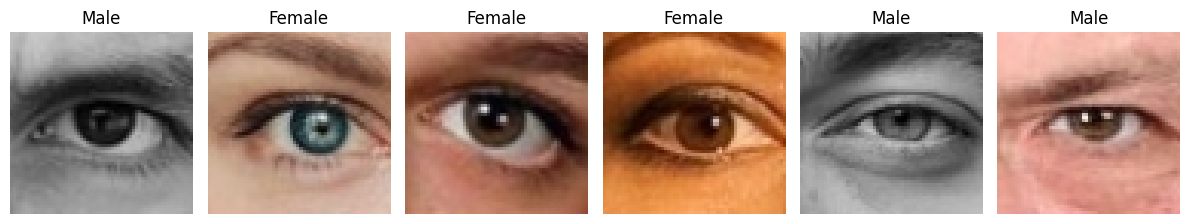

In [6]:
label_names = {0: "Female", 1: "Male"}

plt.figure(figsize=(12, 4))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(cv2.cvtColor((X_arr[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.title(label_names[y_arr[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 6: Split Data into Train and Test Sets
#### Manually splitting the data into Train and Test (70% and 30%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_arr,
    y_arr,
    test_size=0.3,       # 30% goes to testing
    random_state=9       # same seed as malaria project so results are reproducible
)

In [8]:
print("Training samples:", len(X_train))

Training samples: 6454


In [9]:
print("Testing samples: ", len(X_test))

Testing samples:  2766


## Step 7: Building the CNN Model

In [10]:

# Build the model
model = MobileNetV2(input_shape=(60, 60, 3), include_top=False)

# Show the summary
model.summary()


C:\Users\chukw\AppData\Local\Temp\ipykernel_15768\1708141955.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(input_shape=(60, 60, 3), include_top=False)


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 60, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 30, 30,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 30, 30,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 30, 30,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 30, 30,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 30, 30,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 30, 30,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 30, 30,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 30, 30,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 30, 30,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 30, 30,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 30, 30,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 31, 31,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 15, 15,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 15, 15,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 15, 15,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 15, 15,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Step 8: Compiling the Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Base model (feature extractor)
base_model = MobileNetV2(input_shape=(60,60,3), include_top=False, weights='imagenet')

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)   # Flatten feature maps
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary classification

## Step 9: Training the Model

In [ ]:

# Build final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    X_train, y_train,
    epochs=30,
    verbose=1,
    validation_split=0.25
)


C:\Users\chukw\AppData\Local\Temp\ipykernel_15768\2467481611.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(60,60,3), include_top=False, weights='imagenet')


Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 104ms/step - accuracy: 0.8539 - loss: 0.3421 - val_accuracy: 0.8203 - val_loss: 2.4768
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.9291 - loss: 0.1944 - val_accuracy: 0.5849 - val_loss: 7.3978
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.9419 - loss: 0.1494 - val_accuracy: 0.7311 - val_loss: 4.6976
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.9500 - loss: 0.1398 - val_accuracy: 0.8668 - val_loss: 1.9300
Epoch 5/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.9653 - loss: 0.0913 - val_accuracy: 0.7670 - val_loss: 4.2392
Epoch 6/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.9723 - loss: 0.0752 - val_accuracy: 0.8817 - val_loss: 1.5761
Epoch 7/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.9769 - loss: 0.0655 - val_accuracy: 0.8903 - val_loss: 2.0487
Epoch 8/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.9744 - loss: 0.072

## Step 10: Plot Training History

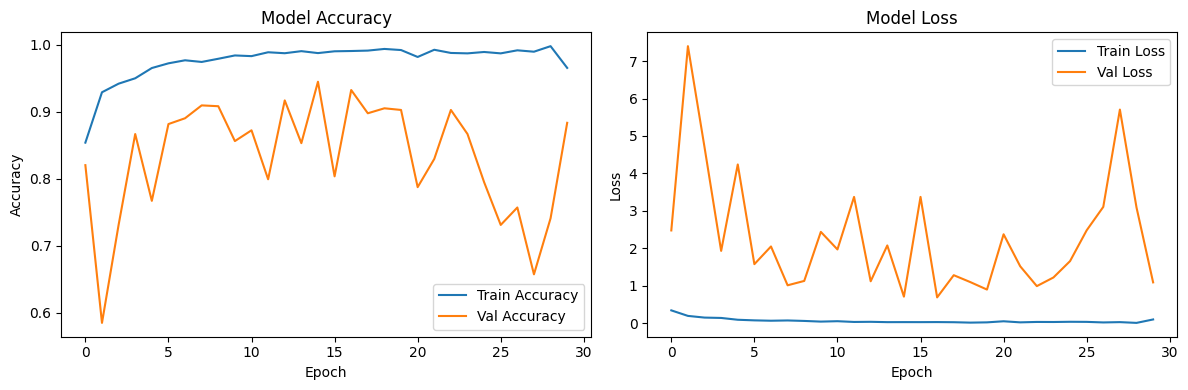

In [16]:
# --- Accuracy Plot ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 11: Evaluation on the Test Set

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss:     1.1503
Test Accuracy: 87.02%


### The system Averaged 87.02% in accuracy on both Classes

## Step 12: Save the Model

In [19]:
model.save("eye_gender_model.keras")
print("Model saved successfully!")

Model saved successfully!


# Therefore,
## Using MobileNetV2 as the backbone for this CNN allowed me to efficiently leverage transfer learning on the Eye‑Gender dataset. The model achieved an accuracy of 87.02%, demonstrating that lightweight architectures can deliver strong performance even on specialized tasks like gender prediction from eye images. This highlights the practical value of MobileNet in exam‑style projects where both accuracy and computational efficiency are critical.

## I HOPE WITH THESE FEW POINTS OF MINE, I HAVE BEEN ABLE TO CONVINCE YOU NOT CONFUSE YOU DO I CAN CODE A CNN(CONVOLUTIONAL NEURAL NETWORK) MODEL. THANK YOU

# CODED BY OFOR EBUKA

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------